Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 63.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.59MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 19.1MB/s]


Train samples: 60000
Test samples : 10000
Image shape  : torch.Size([1, 28, 28])
Pixel range  : 0.0 to 1.0


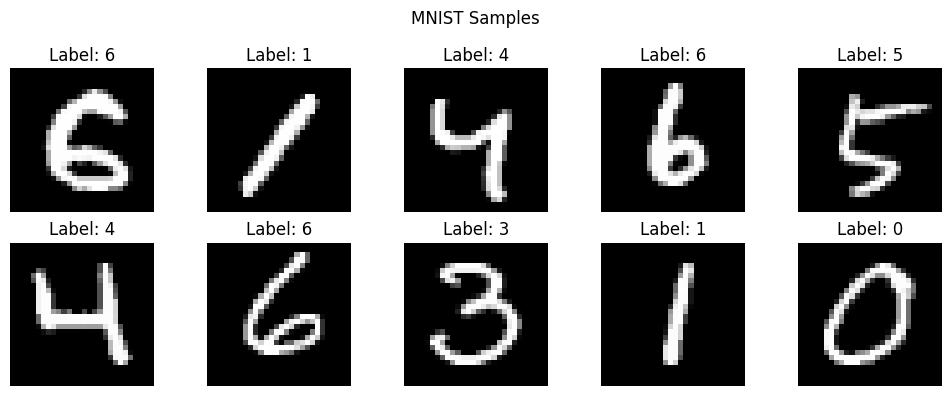

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),  
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(
    test_dataset, batch_size=128, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples : {len(test_dataset)}")

# Visualize some digits
images, labels = next(iter(train_loader))
print(f"Image shape  : {images[0].shape}")
print(f"Pixel range  : {images.min():.1f} to {images.max():.1f}")

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')
plt.suptitle('MNIST Samples')
plt.tight_layout()
plt.show()

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)  
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)  
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  
        )
    
    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)  
        eps = torch.randn_like(std) 
        return mu + eps * std            
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        mu, log_var = self.encode(x)
        
        z = self.reparameterize(mu, log_var)
        
        x_reconstructed = self.decode(z)
        
        return x_reconstructed, mu, log_var


INPUT_DIM  = 28 * 28  
HIDDEN_DIM = 512
LATENT_DIM = 32       
vae = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
print(f"Total parameters: {sum(p.numel() for p in vae.parameters()):,}")

test_input = torch.randn(4, 1, 28, 28).to(device)
recon, mu, log_var = vae(test_input)
print(f"Input shape        : {test_input.shape}")
print(f"Reconstructed shape: {recon.shape}")
print(f"mu shape           : {mu.shape}")
print(f"log_var shape      : {log_var.shape}")

Total parameters: 1,379,152
Input shape        : torch.Size([4, 1, 28, 28])
Reconstructed shape: torch.Size([4, 784])
mu shape           : torch.Size([4, 32])
log_var shape      : torch.Size([4, 32])


In [ ]:
def vae_loss(x_reconstructed, x_original, mu, log_var, beta=1.0):
    x_original = x_original.view(x_original.size(0), -1)

    reconstruction_loss = F.binary_cross_entropy(
        x_reconstructed, x_original, reduction='sum')
    
    
    kl_divergence = -0.5 * torch.sum(
        1 + log_var - mu.pow(2) - log_var.exp())

    return reconstruction_loss + beta * kl_divergence


optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
n_epochs  = 30

train_losses = []

print("Training VAE...")
for epoch in range(n_epochs):
    vae.train()
    total_loss = 0
    
    for images, _ in train_loader: 
        images = images.to(device)
        
        optimizer.zero_grad()
        x_recon, mu, log_var = vae(images)
        loss = vae_loss(x_recon, images, mu, log_var)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | Loss: {avg_loss:.2f}")

print("Training complete!")

Training VAE...
Epoch   5/30 | Loss: 109.90
Epoch  10/30 | Loss: 103.69
Epoch  15/30 | Loss: 101.07
Epoch  20/30 | Loss: 99.61
Epoch  25/30 | Loss: 98.69
Epoch  30/30 | Loss: 98.05
Training complete!


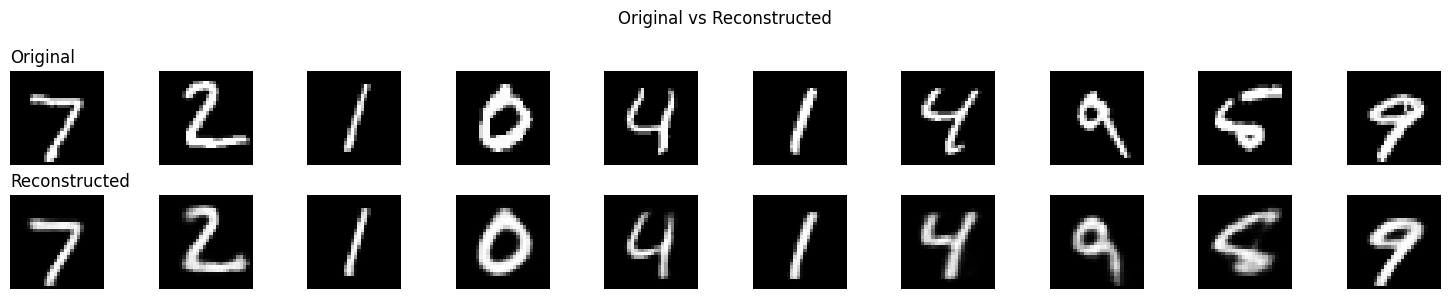

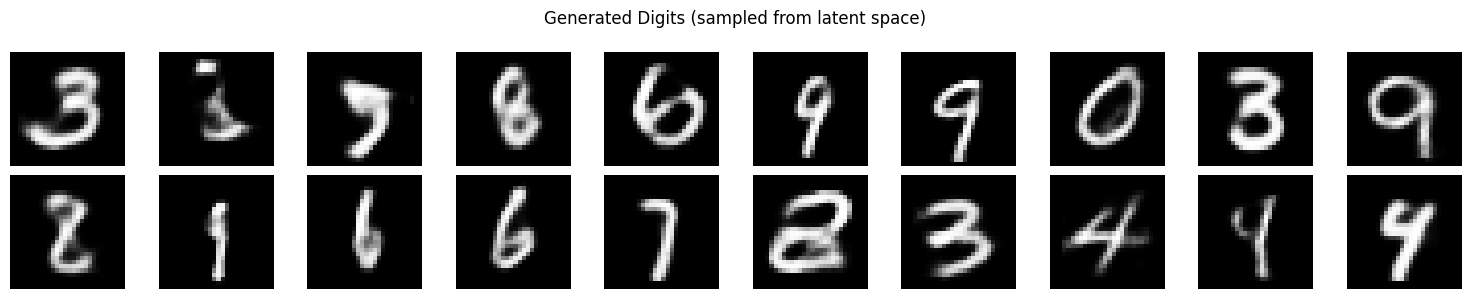

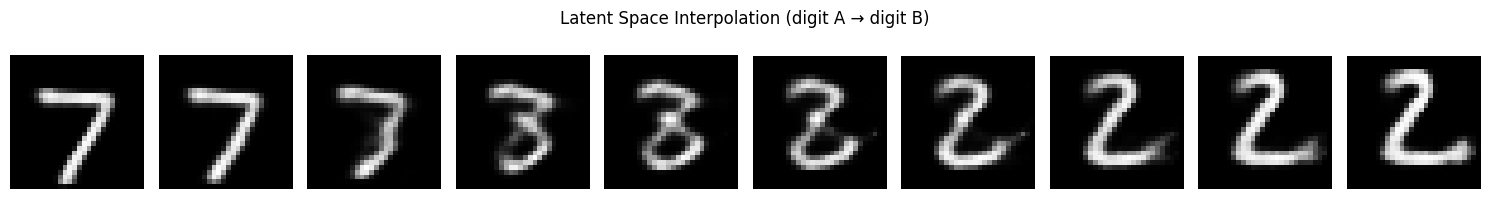

In [ ]:
vae.eval()
with torch.no_grad():
    test_images, test_labels = next(iter(test_loader))
    test_images = test_images.to(device)
    
    recon, mu, log_var = vae(test_images)
    recon = recon.view(-1, 1, 28, 28)  

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title('Original', loc='left')
    
    axes[1, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title('Reconstructed', loc='left')

plt.suptitle('Original vs Reconstructed')
plt.tight_layout()
plt.show()

with torch.no_grad():
    z = torch.randn(20, LATENT_DIM).to(device)
    generated = vae.decode(z)
    generated = generated.view(-1, 1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
axes = axes.flatten()
for i in range(20):
    axes[i].imshow(generated[i].cpu().squeeze(), cmap='gray')
    axes[i].axis('off')

plt.suptitle('Generated Digits (sampled from latent space)')
plt.tight_layout()
plt.show()


with torch.no_grad():
    img1 = test_images[0:1]   
    img2 = test_images[1:2]   
    
    mu1, _ = vae.encode(img1.view(1, -1))
    mu2, _ = vae.encode(img2.view(1, -1))
    
    steps = 10
    interpolated = []
    for alpha in np.linspace(0, 1, steps):
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        decoded   = vae.decode(z_interp)
        interpolated.append(decoded.view(28, 28).cpu())

fig, axes = plt.subplots(1, steps, figsize=(15, 2))
for i, img in enumerate(interpolated):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
plt.suptitle('Latent Space Interpolation (digit A → digit B)')
plt.tight_layout()
plt.show()